# VR Non-Grid Spatial Cell Catalogue

## What this notebook produces

A browsable catalogue of **trial-by-trial firing rate profiles** for non-grid spatial (NGS) cells
recorded in the VR 1D track, separated by medial-lateral position in MEC.

Each panel shows:
- **Top**: average firing rate profile (mean across all trials)
- **Bottom**: trial-by-trial heatmap — rows = trials (chronological, bottom = earliest),
  columns = track position (0–200 cm), colour = firing rate (bone_r; per-cell 0–95th percentile)

Faint vertical lines mark feature boundaries (30, 90, 110, 170 cm).

### Filters
| Filter | Value |
|--------|-------|
| Brain region | `brain_region` starts with `ENTm` |
| Cell type | `cell_type == 'NGS'`, `firing_rate_VR < 10 Hz` |
| Trials | **All trials** (all types, all outcomes) |
| ML split | `|SC_x| ≤ 3400 µm` → Medial; `> 3400 µm` → Lateral |

### Outputs
- `catalogue_medial_NGS.pdf`
- `catalogue_lateral_NGS.pdf`

Requires `vr_eta2_population.csv` (from `vr_feature_correlation.ipynb`) in the same directory.

In [6]:
import numpy as np
import pandas as pd
import pynapple as nap
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.backends.backend_pdf import PdfPages
from scipy.ndimage import gaussian_filter1d
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, '/Users/harryclark/Documents/spatial-manifolds/src')
from spatial_manifolds.detect_grids import curate_clusters

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
source_path         = '/Users/harryclark/Downloads/COHORT12/'
CLASSIFICATIONS_CSV = '/Users/harryclark/Documents/spatial-manifolds/data/cell_classifications.csv'
ETA2_CSV            = 'vr_eta2_population.csv'

TRACK_LEN  = 200.0
N_BINS     = 100
SIGMA      = 1.5      # spatial smoothing (bins)
MIN_TRIALS = 5        # minimum trials to include a session
ML_SPLIT   = 3400     # medial / lateral boundary (µm)
N_COLS     = 4        # cells per row in the catalogue grid

bin_edges   = np.linspace(0, TRACK_LEN, N_BINS + 1)
bin_centres = (bin_edges[:-1] + bin_edges[1:]) / 2.0

BOUNDARY_X  = [30, 90, 110, 170]   # feature boundary positions (cm)
SANITY_MOUSE = 29
SANITY_DAY   = 23

In [8]:
def load_vr_session(mouse, day, source_path):
    sf = f'{source_path}M{mouse}/D{day:02}/VR/'
    beh      = nap.load_file(sf + f'sub-{mouse}_day-{day:02}_ses-VR_beh.nwb')
    clusters = curate_clusters(
        nap.load_file(sf + f'sub-{mouse}_day-{day:02}_ses-VR_srt-kilosort4_clusters.npz')
    )
    return beh, clusters


def get_all_trials_epoch(beh):
    """Return all trials as an IntervalSet with no trial-type filtering."""
    return beh['trials']


def compute_trial_profiles(cluster_ts, position, ep_trials,
                           n_bins=N_BINS, track_len=TRACK_LEN, sigma=SIGMA):
    """Fast numpy trial-by-trial firing rate matrix.

    Returns (n_trials, n_bins) smoothed rate array (Hz).
    Uses numpy histograms directly to avoid one pynapple call per trial.
    """
    edges = np.linspace(0, track_len, n_bins + 1)

    pos_t = np.asarray(position.t)
    pos_v = np.asarray(position.values)
    spk_t = np.asarray(cluster_ts.t)
    dt    = float(np.nanmedian(np.diff(pos_t)))

    mats = []
    for i in range(len(ep_trials)):
        t0, t1 = float(ep_trials.start[i]), float(ep_trials.end[i])

        pm = (pos_t >= t0) & (pos_t <= t1)
        sm = (spk_t >= t0) & (spk_t <= t1)
        tp_v = pos_v[pm]

        occ, _ = np.histogram(tp_v, bins=edges)
        if sm.any() and pm.sum() > 1:
            sp_pos = np.interp(spk_t[sm], pos_t[pm], tp_v)
            spk, _ = np.histogram(sp_pos, bins=edges)
        else:
            spk = np.zeros(n_bins, dtype=int)

        with np.errstate(divide='ignore', invalid='ignore'):
            rate = np.where(occ > 0, spk / (occ * dt), 0.0)
        mats.append(rate)

    mat = np.vstack(mats) if mats else np.zeros((0, n_bins))
    return gaussian_filter1d(mat, sigma=sigma, axis=1)


def draw_cell(ax_avg, ax_heat, mat, cell_id, ml_val, spine_col,
              track_len=TRACK_LEN):
    """Draw avg profile (ax_avg) + trial heatmap (ax_heat) for one cell."""
    n_trials = mat.shape[0]
    avg      = mat.mean(axis=0)
    vmax     = max(np.nanpercentile(mat, 95), 0.1)

    # ── Average profile ───────────────────────────────────────────────────────
    ax_avg.fill_between(bin_centres, avg, alpha=0.55, color='#37474F', lw=0)
    ax_avg.plot(bin_centres, avg, color='#1A237E', lw=0.9)
    for x in BOUNDARY_X:
        ax_avg.axvline(x, color='#78909C', lw=0.5, alpha=0.6, ls='-')
    ax_avg.set_xlim(0, track_len)
    ax_avg.set_xticks([])
    ax_avg.set_yticks([])
    ax_avg.spines[['top','right','bottom']].set_visible(False)
    ax_avg.spines['left'].set_color(spine_col)
    ax_avg.spines['left'].set_linewidth(1.5)
    ax_avg.set_title(f'c{cell_id}  {ml_val:.0f} µm', fontsize=6, pad=2,
                     color=spine_col, fontweight='bold')

    # ── Heatmap ───────────────────────────────────────────────────────────────
    ax_heat.imshow(
        mat, aspect='auto', origin='lower', cmap='bone_r',
        vmin=0, vmax=vmax,
        extent=[0, track_len, 0.5, n_trials + 0.5],
        interpolation='nearest',
    )
    for x in BOUNDARY_X:
        ax_heat.axvline(x, color='#78909C', lw=0.5, alpha=0.5, ls='-')
    ax_heat.set_xlim(0, track_len)
    ax_heat.set_ylim(0.5, n_trials + 0.5)
    ax_heat.set_xticks([])
    ax_heat.set_yticks([])
    for spine in ax_heat.spines.values():
        spine.set_color(spine_col)
        spine.set_linewidth(1.2)

---
## Build NGS cell list

In [9]:
df_pop = pd.read_csv(ETA2_CSV)[['mouse','day','cluster_id','brain_region']]

df_class = pd.read_csv(CLASSIFICATIONS_CSV)[
    ['mouse','day','cluster_id','SC_x','cell_type','firing_rate_VR']
].copy()
df_class['ml']    = df_class['SC_x'].abs()
df_class['mouse'] = df_class['mouse'].astype(int)
df_class['day']   = df_class['day'].astype(int)
df_pop['mouse']   = df_pop['mouse'].astype(int)
df_pop['day']     = df_pop['day'].astype(int)

df_ngs = df_pop.merge(df_class, on=['mouse','day','cluster_id'], how='inner')
df_ngs = df_ngs[
    df_ngs['brain_region'].str.startswith('ENTm', na=False) &
    (df_ngs['firing_rate_VR'] < 10) &
    (df_ngs['cell_type'] == 'NG')
].copy()
df_ngs['medial'] = df_ngs['ml'] <= ML_SPLIT

print(f'NGS MEC principal cells: {len(df_ngs)}')
print(f'  Medial  (<=  {ML_SPLIT} µm): {df_ngs["medial"].sum()}')
print(f'  Lateral (>   {ML_SPLIT} µm): {(~df_ngs["medial"]).sum()}')
print(f'  Sessions: {df_ngs[["mouse","day"]].drop_duplicates().shape[0]}')

NGS MEC principal cells: 3970
  Medial  (<=  3400 µm): 1175
  Lateral (>   3400 µm): 2795
  Sessions: 59


---
## Sanity check — M29 D23

M29 D23: 93 NGS cells
All trials: 149


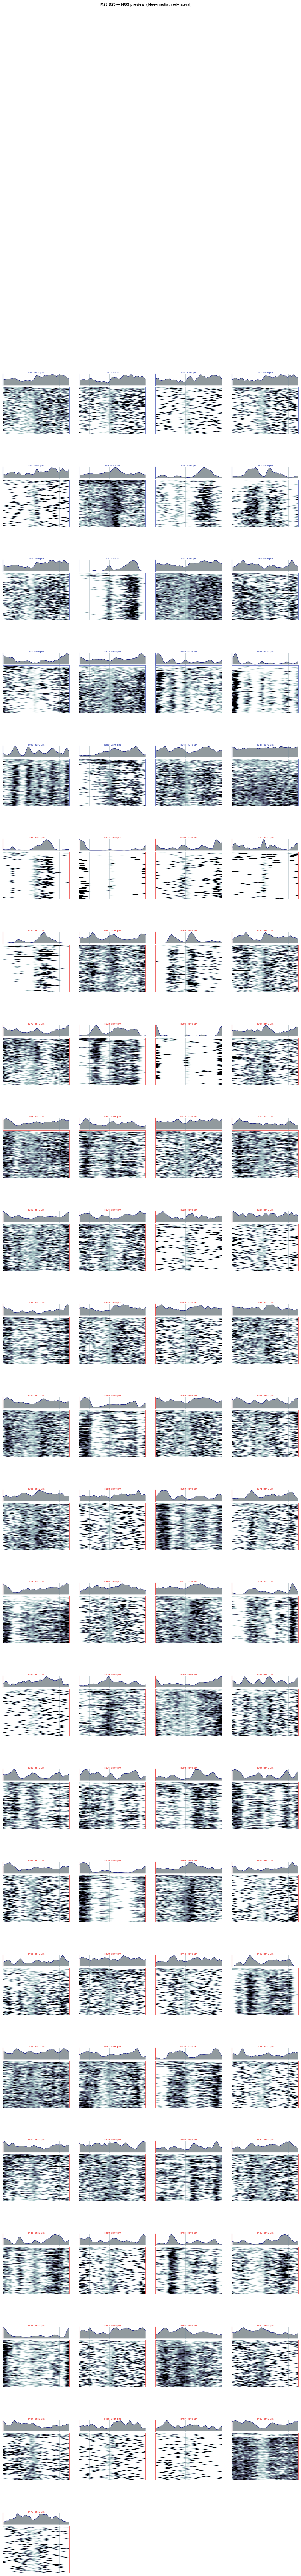

In [10]:
_s_cells = df_ngs[(df_ngs['mouse'] == SANITY_MOUSE) & (df_ngs['day'] == SANITY_DAY)]
print(f'M{SANITY_MOUSE} D{SANITY_DAY}: {len(_s_cells)} NGS cells')

beh_s, clust_s = load_vr_session(SANITY_MOUSE, SANITY_DAY, source_path)
ep_s  = get_all_trials_epoch(beh_s)
pos_s = beh_s['P']
print(f'All trials: {len(ep_s)}')

n_cells = len(_s_cells)
n_cols_s = min(n_cells, N_COLS)
n_rows_s = int(np.ceil(n_cells / n_cols_s))

fig = plt.figure(figsize=(n_cols_s * 3.2, n_rows_s * 4.0))
outer = gridspec.GridSpec(n_rows_s, n_cols_s, figure=fig,
                          hspace=0.55, wspace=0.15)

for idx, (_, row) in enumerate(_s_cells.reset_index(drop=True).iterrows()):
    cid     = int(row['cluster_id'])
    ri, ci  = divmod(idx, n_cols_s)
    inner   = gridspec.GridSpecFromSubplotSpec(
                  2, 1, subplot_spec=outer[ri, ci],
                  height_ratios=[1, 4], hspace=0.04)
    ax_avg  = fig.add_subplot(inner[0])
    ax_heat = fig.add_subplot(inner[1])

    if cid not in clust_s.index:
        ax_avg.axis('off'); ax_heat.axis('off')
        continue

    mat       = compute_trial_profiles(clust_s[cid], pos_s, ep_s)
    spine_col = '#5C6BC0' if row['medial'] else '#EF5350'
    draw_cell(ax_avg, ax_heat, mat, cid, row['ml'], spine_col)

fig.suptitle(f'M{SANITY_MOUSE} D{SANITY_DAY} — NGS preview  '
             f'(blue=medial, red=lateral)',
             fontsize=9, fontweight='bold', y=1.01)
plt.show()

---
## Full catalogue — all sessions

Outputs:
- `catalogue_medial_NGS.pdf`
- `catalogue_lateral_NGS.pdf`

In [11]:
sessions = (df_ngs[['mouse','day']]
            .drop_duplicates()
            .sort_values(['mouse','day'])
            .reset_index(drop=True))

print(f'Building catalogues for {len(sessions)} sessions ...')

with PdfPages('catalogue_medial_NGS.pdf')  as pdf_med, \
     PdfPages('catalogue_lateral_NGS.pdf') as pdf_lat:

    for _, sess in sessions.iterrows():
        mouse, day = int(sess['mouse']), int(sess['day'])
        sess_cells = df_ngs[(df_ngs['mouse'] == mouse) & (df_ngs['day'] == day)]

        vr_dir = Path(source_path) / f'M{mouse}' / f'D{day:02}' / 'VR'
        if not vr_dir.exists():
            print(f'  M{mouse} D{day:02}: no VR directory — skip')
            continue

        try:
            beh, clusters = load_vr_session(mouse, day, source_path)
        except Exception as e:
            print(f'  M{mouse} D{day:02}: load error — {e}')
            continue

        ep_all = get_all_trials_epoch(beh)
        if len(ep_all) < MIN_TRIALS:
            print(f'  M{mouse} D{day:02}: only {len(ep_all)} trials — skip')
            continue

        pos = beh['P']

        for group_label, flag, pdf in [('Medial', True, pdf_med),
                                        ('Lateral', False, pdf_lat)]:
            group = sess_cells[sess_cells['medial'] == flag].reset_index(drop=True)
            if len(group) == 0:
                continue

            n_cells   = len(group)
            n_rows    = int(np.ceil(n_cells / N_COLS))
            spine_col = '#5C6BC0' if flag else '#EF5350'

            fig = plt.figure(figsize=(N_COLS * 3.2, n_rows * 4.0))
            outer = gridspec.GridSpec(n_rows, N_COLS, figure=fig,
                                      hspace=0.55, wspace=0.15)

            for idx, row in group.iterrows():
                cid    = int(row['cluster_id'])
                ri, ci = divmod(idx, N_COLS)
                inner  = gridspec.GridSpecFromSubplotSpec(
                             2, 1, subplot_spec=outer[ri, ci],
                             height_ratios=[1, 4], hspace=0.04)
                ax_avg  = fig.add_subplot(inner[0])
                ax_heat = fig.add_subplot(inner[1])

                if cid not in clusters.index:
                    ax_avg.axis('off'); ax_heat.axis('off')
                    continue

                try:
                    mat = compute_trial_profiles(clusters[cid], pos, ep_all)
                    draw_cell(ax_avg, ax_heat, mat, cid, row['ml'], spine_col)
                except Exception as e:
                    ax_avg.axis('off'); ax_heat.axis('off')
                    ax_heat.text(0.5, 0.5, f'c{cid}\nERROR', ha='center',
                                 va='center', fontsize=6, transform=ax_heat.transAxes)

            # Hide unused slots
            for idx in range(n_cells, n_rows * N_COLS):
                ri, ci = divmod(idx, N_COLS)
                inner  = gridspec.GridSpecFromSubplotSpec(
                             2, 1, subplot_spec=outer[ri, ci])
                fig.add_subplot(inner[0]).axis('off')
                fig.add_subplot(inner[1]).axis('off')

            ml_range = f'{group["ml"].min():.0f}–{group["ml"].max():.0f} µm'
            fig.suptitle(
                f'M{mouse} D{day:02}  —  {group_label} NGS  '
                f'(n={n_cells},  {len(ep_all)} trials,  '
                f'|SC_x|: {ml_range})',
                fontsize=8.5, fontweight='bold',
            )

            pdf.savefig(fig, bbox_inches='tight')
            plt.close(fig)
            print(f'  M{mouse} D{day:02}  {group_label}: {n_cells} cells')

print('\nDone.')
print('  catalogue_medial_NGS.pdf')
print('  catalogue_lateral_NGS.pdf')

Building catalogues for 59 sessions ...
  M20 D14  Medial: 22 cells
  M20 D14  Lateral: 50 cells
  M20 D15  Medial: 21 cells
  M20 D15  Lateral: 21 cells
  M20 D16  Medial: 45 cells
  M20 D16  Lateral: 61 cells
  M20 D17  Medial: 17 cells
  M20 D17  Lateral: 40 cells
  M20 D18  Medial: 25 cells
  M20 D18  Lateral: 45 cells
  M20 D19  Medial: 22 cells
  M20 D19  Lateral: 42 cells
  M20 D20  Medial: 66 cells
  M20 D21  Lateral: 51 cells
  M20 D22  Lateral: 55 cells
  M20 D23  Medial: 38 cells
  M20 D24  Lateral: 50 cells
  M20 D25  Medial: 12 cells
  M20 D26  Lateral: 104 cells
  M21 D15  Lateral: 160 cells
  M21 D16  Medial: 36 cells
  M21 D16  Lateral: 105 cells
  M21 D17  Lateral: 176 cells
  M21 D18  Lateral: 131 cells
  M21 D19  Lateral: 158 cells
  M21 D20  Lateral: 131 cells
  M21 D21  Medial: 101 cells
  M21 D22  Lateral: 75 cells
  M21 D23  Lateral: 121 cells
  M21 D24  Lateral: 78 cells
  M21 D25  Lateral: 57 cells
  M21 D26  Medial: 71 cells
  M25 D16  Lateral: 11 cells
  M25 